# CS 全量滤波管线 Demo（冻结）

> **此 notebook 为算法步骤演示，后期不再修改。**
> 日常评估请使用 `glb_cs_segment_breath_analysis.ipynb`。

流程：全通道提取 → 中值/Hampel 去尖刺 → 高通去趋势 → 呼吸窗能量判定 → 带通滤波。


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# 必须先加入 src/，再 import ble_analysis
_cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [_cwd, *_cwd.parents] if (p / "src").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("未找到项目根目录（缺少 src/ 目录）")

_src = project_root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from ble_analysis.bootstrap import init_notebook

_env = init_notebook(project_root)
project_root = _env["project_root"]
FIGURES_DIR = _env["FIGURES_DIR"]
PROCESSED_DIR = _env["PROCESSED_DIR"]
REPORTS_DIR = _env["REPORTS_DIR"]
from ble_analysis.data import load_ble_frames
from ble_analysis.filters import apply_filter_pipeline

out_dir = project_root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)



In [2]:
filepath = project_root / "sampleData" / "CS_frames_all_20260113_091339.jsonl"
data, frames = load_ble_frames(filepath)


✓ 找到文件: D:\Work\atomic\ble_hci_sensing\sampleData\CS_frames_all_20260113_091339.jsonl
文件大小: 10.71 MB
正在加载: D:\Work\atomic\ble_hci_sensing\sampleData\CS_frames_all_20260113_091339.jsonl
✓ 加载成功
✓ 共加载 733 帧数据


## add.1 滤除尖刺
此项使用中值滤波或hampel 滤波，去除幅值/相位信息中的尖刺，要点是窗口需要尽可能接近突变尖刺的宽度，且远远不及呼吸的长度。也就是1-3个点左右（对于2Hz采样率来说）。hampel一般默认$\delta=3$

### 中值
在每一个时间点 $n$：
1. 取一个**很短的局部窗口**
   $\{x[n-k], \dots, x[n], \dots, x[n+k]\}$
2. **排序**
3. 用**中位数**替代当前值
### hampel
在窗口内计算：
- 中位数：
  $m = \text{median}(x)$
- 中位绝对偏差（MAD）：
  $\text{MAD} = \text{median}(|x - m|)$
用 MAD 估计标准差：
$\sigma \approx 1.4826 \cdot \text{MAD}$
#### ✅ 判决规则
$|x[n] - m| > \gamma \sigma$

- 若成立 → 认为是异常 → 用中位数替换
- 否则 → 保留原值
#### ✅ Hampel 需要阈值吗？

> **需要，但阈值非常“通用”**

- $\gamma = 3$（几乎是默认值）

In [3]:
# 对所有信道幅值/相位分别应用中值滤波和hampel 滤波，然后对照效果

# 提取所有通道的所有变量数据
print("正在提取所有通道的数据...")
all_channels_data = {}

if frames:
    # 获取所有通道号
    all_channels = set()
    for frame in frames:
        channels = frame.get("channels", {})
        all_channels.update(channels.keys())

    all_channels = sorted(
        [int(ch) if isinstance(ch, str) and ch.isdigit() else ch for ch in all_channels]
    )
    print(f"找到 {len(all_channels)} 个通道")

    # 为每个通道提取数据
    for ch in all_channels:
        ch_str = str(ch)
        ch_data_dict = {
            "amplitudes": [],
            "phases": [],
            "local_amplitudes": [],
            "remote_amplitudes": [],
            "local_phases": [],
            "remote_phases": [],
            "timestamps_ms": [],
        }

        for frame in frames:
            channels = frame.get("channels", {})
            ch_data = None

            # 尝试多种方式匹配通道
            if ch in channels:
                ch_data = channels[ch]
            elif ch_str in channels:
                ch_data = channels[ch_str]
            elif int(ch) in channels:
                ch_data = channels[int(ch)]

            if ch_data:
                ch_data_dict["amplitudes"].append(ch_data.get("amplitude", 0))
                ch_data_dict["phases"].append(ch_data.get("phase", 0))
                ch_data_dict["local_amplitudes"].append(
                    ch_data.get("local_amplitude", 0)
                )
                ch_data_dict["remote_amplitudes"].append(
                    ch_data.get("remote_amplitude", 0)
                )
                ch_data_dict["local_phases"].append(ch_data.get("local_phase", 0))
                ch_data_dict["remote_phases"].append(ch_data.get("remote_phase", 0))
                ch_data_dict["timestamps_ms"].append(frame.get("timestamp_ms", 0))

        # 转换为numpy数组，这一步还真是必要的，不知原因
        for key in ch_data_dict:
            ch_data_dict[key] = np.array(ch_data_dict[key])

        all_channels_data[ch] = ch_data_dict

print(f"✓ 成功提取 {len(all_channels_data)} 个通道的数据")

正在提取所有通道的数据...
找到 72 个通道
✓ 成功提取 72 个通道的数据


## ⚠️ 重要：采样率修复

**问题发现：**
- 实际采样率是 **1.55 Hz**（从时间戳计算得出）
- 但代码中使用了固定的 **2.0 Hz**
- 时间间隔不均匀（CV=0.422），可能影响滤波效果

**影响：**
1. 高通滤波的截止频率计算可能不准确
2. FFT频率轴计算可能偏差
3. 时间窗大小计算可能不准确

**解决方案：**
在后续的Cell中，请将 `sampling_rate = 2.0` 改为使用实际计算的采样率：
- 如果Cell 10已运行，使用 `actual_sampling_rate` 变量
- 或者手动计算：`sampling_rate = 1.0 / np.mean(np.diff(timestamps_ms) / 1000.0)`

**需要修改的Cell：**
- Cell 17: 高通滤波（add.2）
- Cell 19: 呼吸存在判定
- Cell 21: 带通滤波（add.3）


正在应用滤波（窗口大小=3，Hampel阈值=3）...
✓ 滤波完成


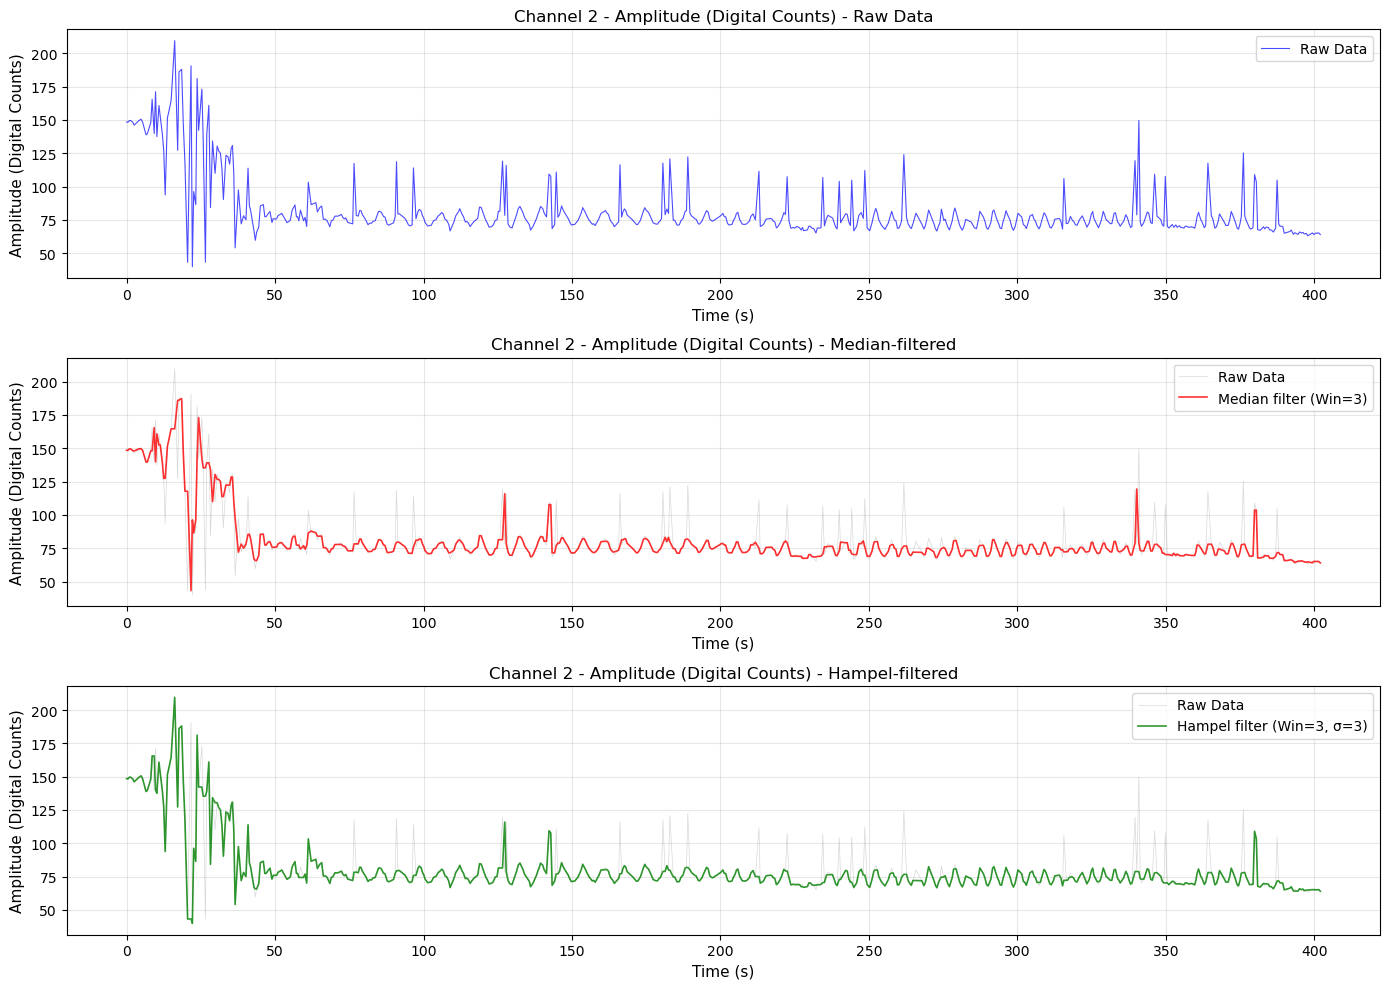

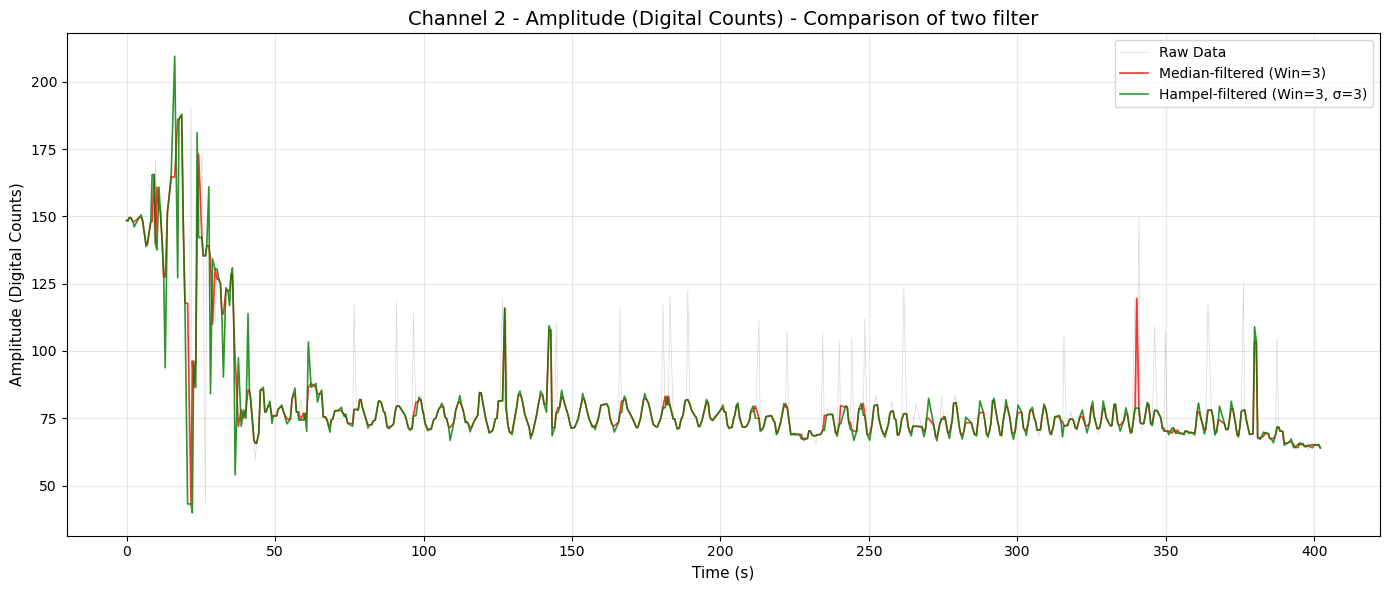


=== 通道 2 - Amplitude (Digital Counts) 滤波效果统计 ===
原始数据:
  均值: 81.9832, 标准差: 22.4332
  最大值: 209.5376, 最小值: 39.8246

中值滤波后:
  均值: 80.7566, 标准差: 20.5858
  最大值: 187.0722, 最小值: 43.1393
  变化点数: 263 / 624

Hampel滤波后:
  均值: 80.3364, 标准差: 20.8475
  最大值: 209.5376, 最小值: 39.8246
  变化点数: 57 / 624


In [4]:
# 对所有通道的所有变量应用中值滤波和Hampel滤波，存储到新dict filtered_data
window_size = 3  # 窗口大小：1-3个点（对于2Hz采样率）
n_sigma = 3  # Hampel滤波的阈值倍数

print(f"\n正在应用滤波（窗口大小={window_size}，Hampel阈值={n_sigma}）...")

filtered_data = {}
for ch in all_channels_data:
    filtered_data[ch] = {}
    ch_data = all_channels_data[ch]

    # 对每个变量进行滤波
    for var_name in [
        "amplitudes",
        "phases",
        "local_amplitudes",
        "remote_amplitudes",
        "local_phases",
        "remote_phases",
    ]:
        if len(ch_data[var_name]) > 0:
            # 中值滤波
            median_filtered = apply_filter_pipeline(
                ch_data[var_name],
                pipeline=[{"type": "median", "window_size": window_size}],
            )
            hampel_filtered = apply_filter_pipeline(
                ch_data[var_name],
                pipeline=[
                    {"type": "hampel", "window_size": window_size, "n_sigma": n_sigma}
                ],
            )

            filtered_data[ch][var_name] = {
                "original": ch_data[var_name],
                "median": median_filtered,
                "hampel": hampel_filtered,
            }

print("✓ 滤波完成")

# 选择任意一个通道和任意一个变量进行可视化比较
# 这里选择通道0的总幅值作为示例
demo_channel = 2
demo_variable = "remote_amplitudes"  # 可以选择: amplitudes, phases, local_amplitudes, remote_amplitudes, local_phases, remote_phases

# 如果通道0不存在，使用第一个可用通道
if demo_channel not in filtered_data and len(filtered_data) > 0:
    demo_channel = list(filtered_data.keys())[0]
    print(f"通道0不存在，使用通道 {demo_channel}")

if demo_channel in filtered_data and demo_variable in filtered_data[demo_channel]:
    # 获取时间轴（转换为秒）
    timestamps_ms = all_channels_data[demo_channel]["timestamps_ms"]
    if len(timestamps_ms) > 0:
        time_sec = (timestamps_ms - timestamps_ms[0]) / 1000.0
    else:
        time_sec = np.arange(
            len(filtered_data[demo_channel][demo_variable]["original"])
        )

    # 获取数据
    original = filtered_data[demo_channel][demo_variable]["original"]
    median_filtered = filtered_data[demo_channel][demo_variable]["median"]
    hampel_filtered = filtered_data[demo_channel][demo_variable]["hampel"]

    # 绘制对比图
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # 变量名称映射
    var_names = {
        "amplitudes": "Amplitude (Digital Counts)",
        "phases": "Phase (rad)",
        "local_amplitudes": "Amplitude (Digital Counts)",
        "remote_amplitudes": "Amplitude (Digital Counts)",
        "local_phases": "Local Phase (rad)",
        "remote_phases": "Remote Phase (rad)",
    }
    var_display_name = var_names.get(demo_variable, demo_variable)

    # 原始数据
    axes[0].plot(time_sec, original, "b-", linewidth=0.8, alpha=0.7, label="Raw Data")
    axes[0].set_title(
        f"Channel {demo_channel} - {var_display_name} - Raw Data", fontsize=12
    )
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel(var_display_name)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # 中值滤波结果
    axes[1].plot(time_sec, original, "gray", linewidth=0.5, alpha=0.3, label="Raw Data")
    axes[1].plot(
        time_sec,
        median_filtered,
        "r-",
        linewidth=1.2,
        alpha=0.8,
        label=f"Median filter (Win={window_size})",
    )
    axes[1].set_title(
        f"Channel {demo_channel} - {var_display_name} - Median-filtered", fontsize=12
    )
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel(var_display_name)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Hampel滤波结果
    axes[2].plot(time_sec, original, "gray", linewidth=0.5, alpha=0.3, label="Raw Data")
    axes[2].plot(
        time_sec,
        hampel_filtered,
        "g-",
        linewidth=1.2,
        alpha=0.8,
        label=f"Hampel filter (Win={window_size}, σ={n_sigma})",
    )
    axes[2].set_title(
        f"Channel {demo_channel} - {var_display_name} - Hampel-filtered", fontsize=12
    )
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel(var_display_name)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # 绘制两种滤波方法的直接对比
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    ax.plot(time_sec, original, "gray", linewidth=0.5, alpha=0.3, label="Raw Data")
    ax.plot(
        time_sec,
        median_filtered,
        "r-",
        linewidth=1.2,
        alpha=0.8,
        label=f"Median-filtered (Win={window_size})",
    )
    ax.plot(
        time_sec,
        hampel_filtered,
        "g-",
        linewidth=1.2,
        alpha=0.8,
        label=f"Hampel-filtered (Win={window_size}, σ={n_sigma})",
    )
    ax.set_title(
        f"Channel {demo_channel} - {var_display_name} - Comparison of two filter",
        fontsize=14,
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(var_display_name)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # 打印统计信息
    print(f"\n=== 通道 {demo_channel} - {var_display_name} 滤波效果统计 ===")
    print(f"原始数据:")
    print(f"  均值: {np.mean(original):.4f}, 标准差: {np.std(original):.4f}")
    print(f"  最大值: {np.max(original):.4f}, 最小值: {np.min(original):.4f}")
    print(f"\n中值滤波后:")
    print(
        f"  均值: {np.mean(median_filtered):.4f}, 标准差: {np.std(median_filtered):.4f}"
    )
    print(
        f"  最大值: {np.max(median_filtered):.4f}, 最小值: {np.min(median_filtered):.4f}"
    )
    print(f"  变化点数: {np.sum(original != median_filtered)} / {len(original)}")
    print(f"\nHampel滤波后:")
    print(
        f"  均值: {np.mean(hampel_filtered):.4f}, 标准差: {np.std(hampel_filtered):.4f}"
    )
    print(
        f"  最大值: {np.max(hampel_filtered):.4f}, 最小值: {np.min(hampel_filtered):.4f}"
    )
    print(f"  变化点数: {np.sum(original != hampel_filtered)} / {len(original)}")

else:
    print(f"⚠️ 无法找到通道 {demo_channel} 的变量 {demo_variable}")

## add.2 去直流偏置，趋势
- 截止频率：
  - **0.03–0.05 Hz**
- 阶数：
  - **1–2 阶 Butterworth**
- 必须零相位
📌 原因：
- 2 Hz 下，高阶 IIR 很容易畸变


Applying highpass filter to median-filtered data...
Sampling rate: 2.0 Hz
Cutoff frequency: 0.05 Hz
✓ Highpass filtering completed for 72 channels


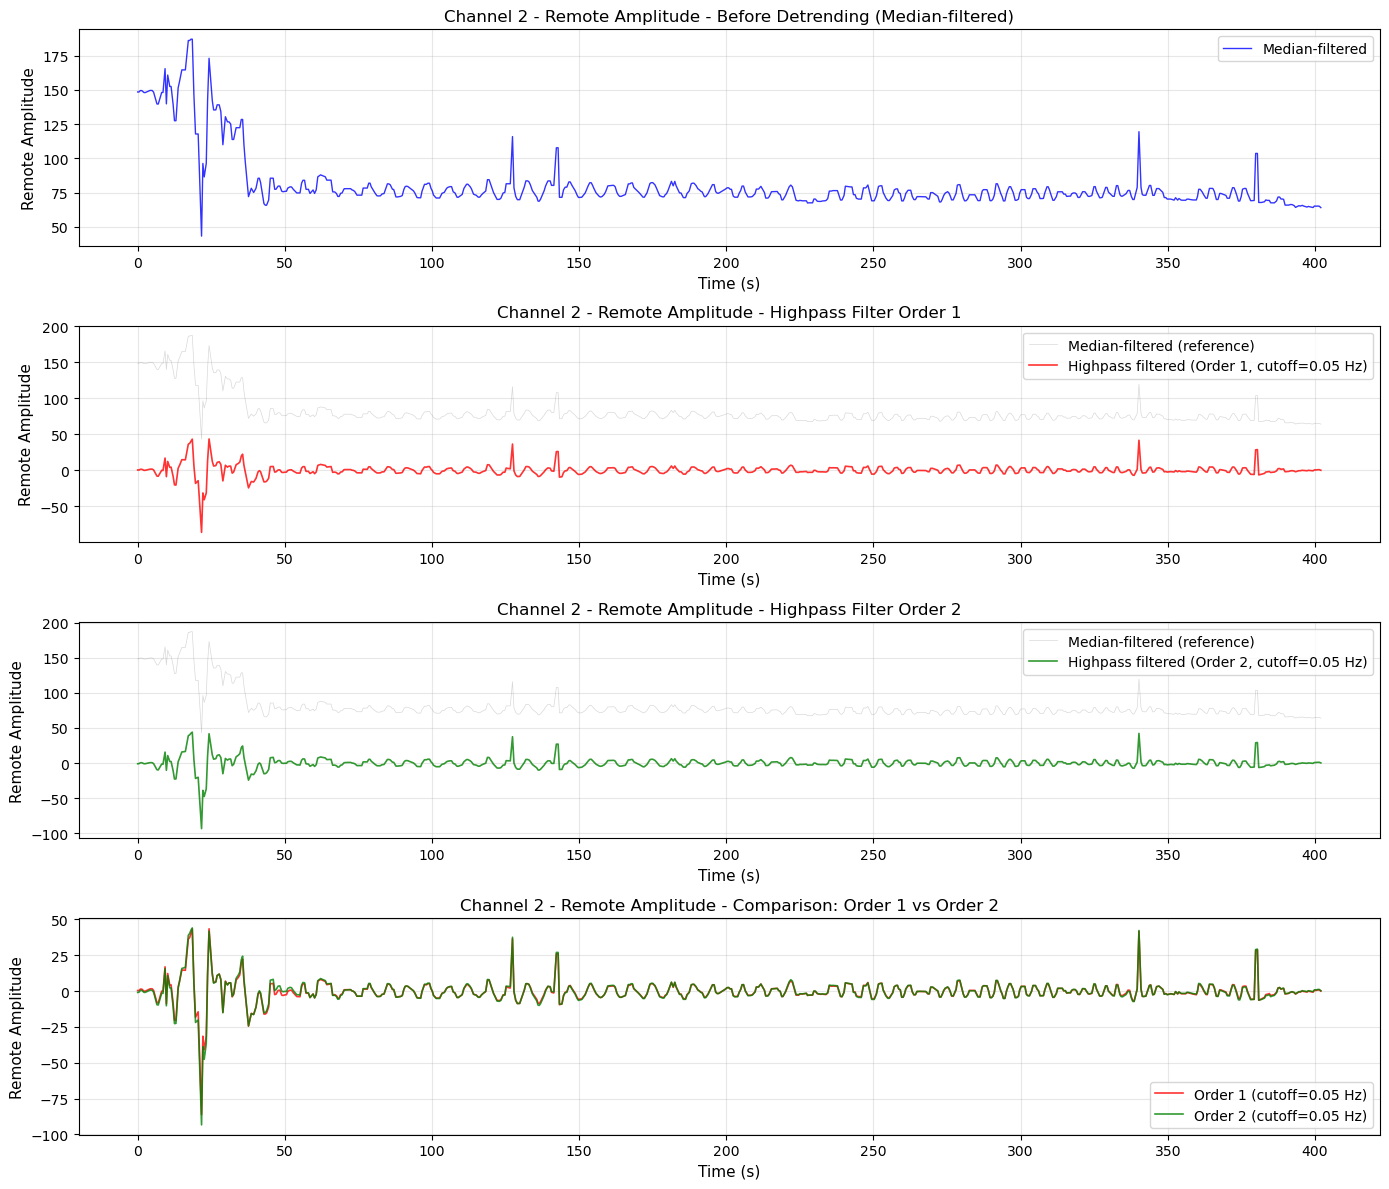


=== Channel 2 - Remote Amplitude - Detrending Statistics ===
Median-filtered (before detrending):
  Mean: 80.7566, Std: 20.5858
  Max: 187.0722, Min: 43.1393

Highpass filtered (Order 1):
  Mean: 0.0153, Std: 7.8698
  Max: 43.4133, Min: -86.1865
  Mean change: 80.7413

Highpass filtered (Order 2):
  Mean: 0.0031, Std: 8.3672
  Max: 44.0131, Min: -93.3459
  Mean change: 80.7534


In [5]:
# Apply highpass filter to median-filtered data for detrending (baseline drift removal)

# Parameters
sampling_rate = 2.0  # Hz (2 Hz sampling rate as mentioned)
cutoff_freq = (
    0.05  # Hz (cutoff frequency for removing baseline drift, adjust as needed)
)

print(f"\nApplying highpass filter to median-filtered data...")
print(f"Sampling rate: {sampling_rate} Hz")
print(f"Cutoff frequency: {cutoff_freq} Hz")

# Apply highpass filter with order 1 and order 2 to all channels and variables
detrended_data = {}

for ch in filtered_data:
    detrended_data[ch] = {}
    ch_filtered = filtered_data[ch]

    # Process each variable
    for var_name in [
        "amplitudes",
        "phases",
        "local_amplitudes",
        "remote_amplitudes",
        "local_phases",
        "remote_phases",
    ]:
        if var_name in ch_filtered and len(ch_filtered[var_name]["median"]) > 0:
            median_filtered = ch_filtered[var_name]["median"]

            detrended_order1 = apply_filter_pipeline(
                median_filtered,
                fs=sampling_rate,
                pipeline=[
                    {"type": "highpass", "cutoff": cutoff_freq, "order": 1},
                ],
            )

            detrended_order2 = apply_filter_pipeline(
                median_filtered,
                fs=sampling_rate,
                pipeline=[
                    {"type": "highpass", "cutoff": cutoff_freq, "order": 2},
                ],
            )

            detrended_data[ch][var_name] = {
                "median_filtered": median_filtered,
                "detrended_order1": detrended_order1,
                "detrended_order2": detrended_order2,
            }

print(f"✓ Highpass filtering completed for {len(detrended_data)} channels")


# Visualize comparison of different filter orders
# Select a channel and variable for demonstration
demo_channel = 2
demo_variable = "remote_amplitudes"  # Can choose: amplitudes, phases, local_amplitudes, remote_amplitudes, local_phases, remote_phases

# If channel 0 doesn't exist, use the first available channel
if demo_channel not in detrended_data and len(detrended_data) > 0:
    demo_channel = list(detrended_data.keys())[0]
    print(f"Channel 0 not found, using channel {demo_channel}")

if demo_channel in detrended_data and demo_variable in detrended_data[demo_channel]:
    # Get time axis (convert to seconds)
    timestamps_ms = all_channels_data[demo_channel]["timestamps_ms"]
    if len(timestamps_ms) > 0:
        time_sec = (timestamps_ms - timestamps_ms[0]) / 1000.0
    else:
        time_sec = np.arange(
            len(detrended_data[demo_channel][demo_variable]["median_filtered"])
        )

    # Get data
    median_filtered = detrended_data[demo_channel][demo_variable]["median_filtered"]
    detrended_1 = detrended_data[demo_channel][demo_variable]["detrended_order1"]
    detrended_2 = detrended_data[demo_channel][demo_variable]["detrended_order2"]

    # Variable name mapping
    var_names = {
        "amplitudes": "Total Amplitude",
        "phases": "Total Phase",
        "local_amplitudes": "Local Amplitude",
        "remote_amplitudes": "Remote Amplitude",
        "local_phases": "Local Phase",
        "remote_phases": "Remote Phase",
    }
    var_display_name = var_names.get(demo_variable, demo_variable)

    # Create comparison plots
    fig, axes = plt.subplots(4, 1, figsize=(14, 12))

    # Plot 1: Median-filtered data (before detrending)
    axes[0].plot(
        time_sec,
        median_filtered,
        "b-",
        linewidth=1.0,
        alpha=0.8,
        label="Median-filtered",
    )
    axes[0].set_title(
        f"Channel {demo_channel} - {var_display_name} - Before Detrending (Median-filtered)",
        fontsize=12,
    )
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel(var_display_name)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Plot 2: Order 1 highpass filter
    axes[1].plot(
        time_sec,
        median_filtered,
        "gray",
        linewidth=0.5,
        alpha=0.3,
        label="Median-filtered (reference)",
    )
    axes[1].plot(
        time_sec,
        detrended_1,
        "r-",
        linewidth=1.2,
        alpha=0.8,
        label=f"Highpass filtered (Order 1, cutoff={cutoff_freq} Hz)",
    )
    axes[1].set_title(
        f"Channel {demo_channel} - {var_display_name} - Highpass Filter Order 1",
        fontsize=12,
    )
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel(var_display_name)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Plot 3: Order 2 highpass filter
    axes[2].plot(
        time_sec,
        median_filtered,
        "gray",
        linewidth=0.5,
        alpha=0.3,
        label="Median-filtered (reference)",
    )
    axes[2].plot(
        time_sec,
        detrended_2,
        "g-",
        linewidth=1.2,
        alpha=0.8,
        label=f"Highpass filtered (Order 2, cutoff={cutoff_freq} Hz)",
    )
    axes[2].set_title(
        f"Channel {demo_channel} - {var_display_name} - Highpass Filter Order 2",
        fontsize=12,
    )
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel(var_display_name)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    # Plot 4: Comparison of both orders
    # axes[3].plot(time_sec, median_filtered, 'gray', linewidth=0.5, alpha=0.3, label='Median-filtered (reference)')
    axes[3].plot(
        time_sec,
        detrended_1,
        "r-",
        linewidth=1.2,
        alpha=0.8,
        label=f"Order 1 (cutoff={cutoff_freq} Hz)",
    )
    axes[3].plot(
        time_sec,
        detrended_2,
        "g-",
        linewidth=1.2,
        alpha=0.8,
        label=f"Order 2 (cutoff={cutoff_freq} Hz)",
    )
    axes[3].set_title(
        f"Channel {demo_channel} - {var_display_name} - Comparison: Order 1 vs Order 2",
        fontsize=12,
    )
    axes[3].set_xlabel("Time (s)")
    axes[3].set_ylabel(var_display_name)
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(
        f"\n=== Channel {demo_channel} - {var_display_name} - Detrending Statistics ==="
    )
    print(f"Median-filtered (before detrending):")
    print(f"  Mean: {np.mean(median_filtered):.4f}, Std: {np.std(median_filtered):.4f}")
    print(f"  Max: {np.max(median_filtered):.4f}, Min: {np.min(median_filtered):.4f}")
    print(f"\nHighpass filtered (Order 1):")
    print(f"  Mean: {np.mean(detrended_1):.4f}, Std: {np.std(detrended_1):.4f}")
    print(f"  Max: {np.max(detrended_1):.4f}, Min: {np.min(detrended_1):.4f}")
    print(f"  Mean change: {np.mean(median_filtered) - np.mean(detrended_1):.4f}")
    print(f"\nHighpass filtered (Order 2):")
    print(f"  Mean: {np.mean(detrended_2):.4f}, Std: {np.std(detrended_2):.4f}")
    print(f"  Max: {np.max(detrended_2):.4f}, Min: {np.min(detrended_2):.4f}")
    print(f"  Mean change: {np.mean(median_filtered) - np.mean(detrended_2):.4f}")

else:
    print(f"⚠️ Cannot find channel {demo_channel} variable {demo_variable}")

## 呼吸存在判定

开始对所有通道和所有变量进行加窗和能量计算...
  已处理 10/72 个通道...
  已处理 20/72 个通道...
  已处理 30/72 个通道...
  已处理 40/72 个通道...
  已处理 50/72 个通道...
  已处理 60/72 个通道...
  已处理 70/72 个通道...
  已处理 72/72 个通道...
✓ 所有通道和变量的加窗和能量计算完成

=== 展示通道 2 的变量 remote_amplitudes ===
信号长度: 624 个样本点
时间窗长度: 20秒 (40个样本点)
步长: 1秒 (2个样本点)
✓ 共生成 293 个时间窗样本
✓ 能量比例计算完成，共 293 个样本
能量比例范围: [0.2188, 0.9809]
平均能量比例: 0.7332


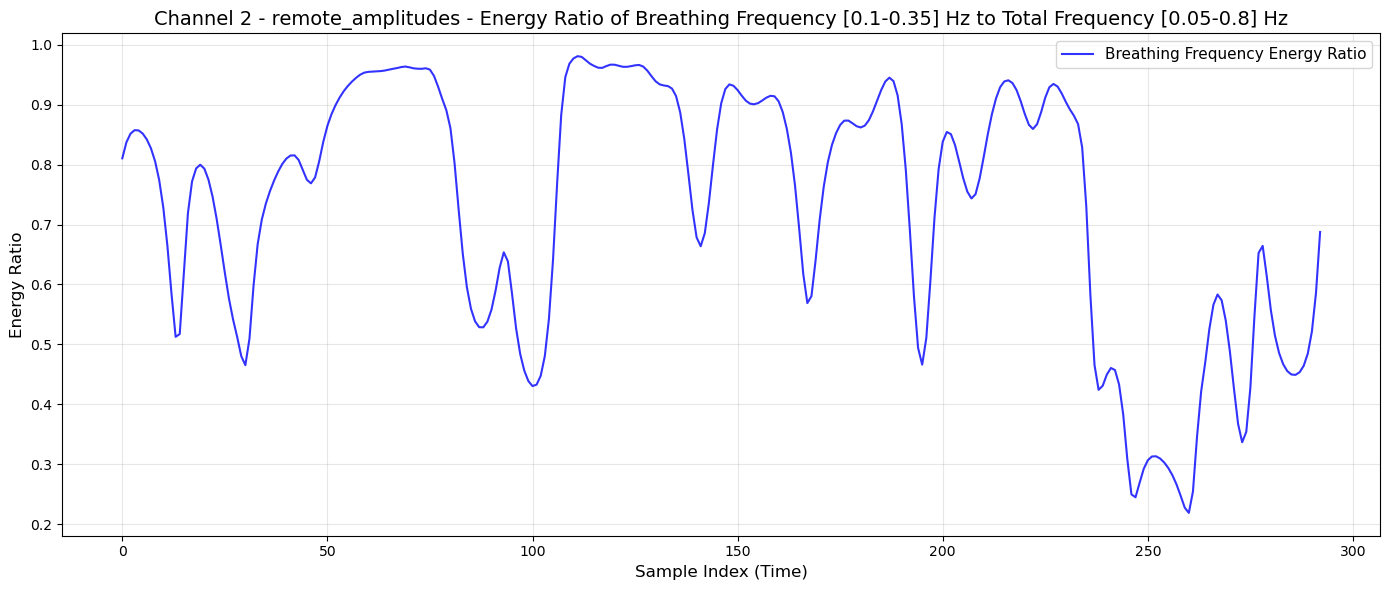


正在收集所有信道的能量占比数据（变量: remote_amplitudes）...
✓ 找到 72 个有效信道
时间窗数量范围: 184 - 345


C:\Users\cwdbo\AppData\Local\Temp\ipykernel_121652\1589698627.py:224: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('tab20')  # 使用tab20 colormap，支持20种不同颜色
C:\Users\cwdbo\AppData\Local\Temp\ipykernel_121652\1589698627.py:226: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('tab20c')  # 如果信道数超过20，使用tab20c（支持更多颜色）


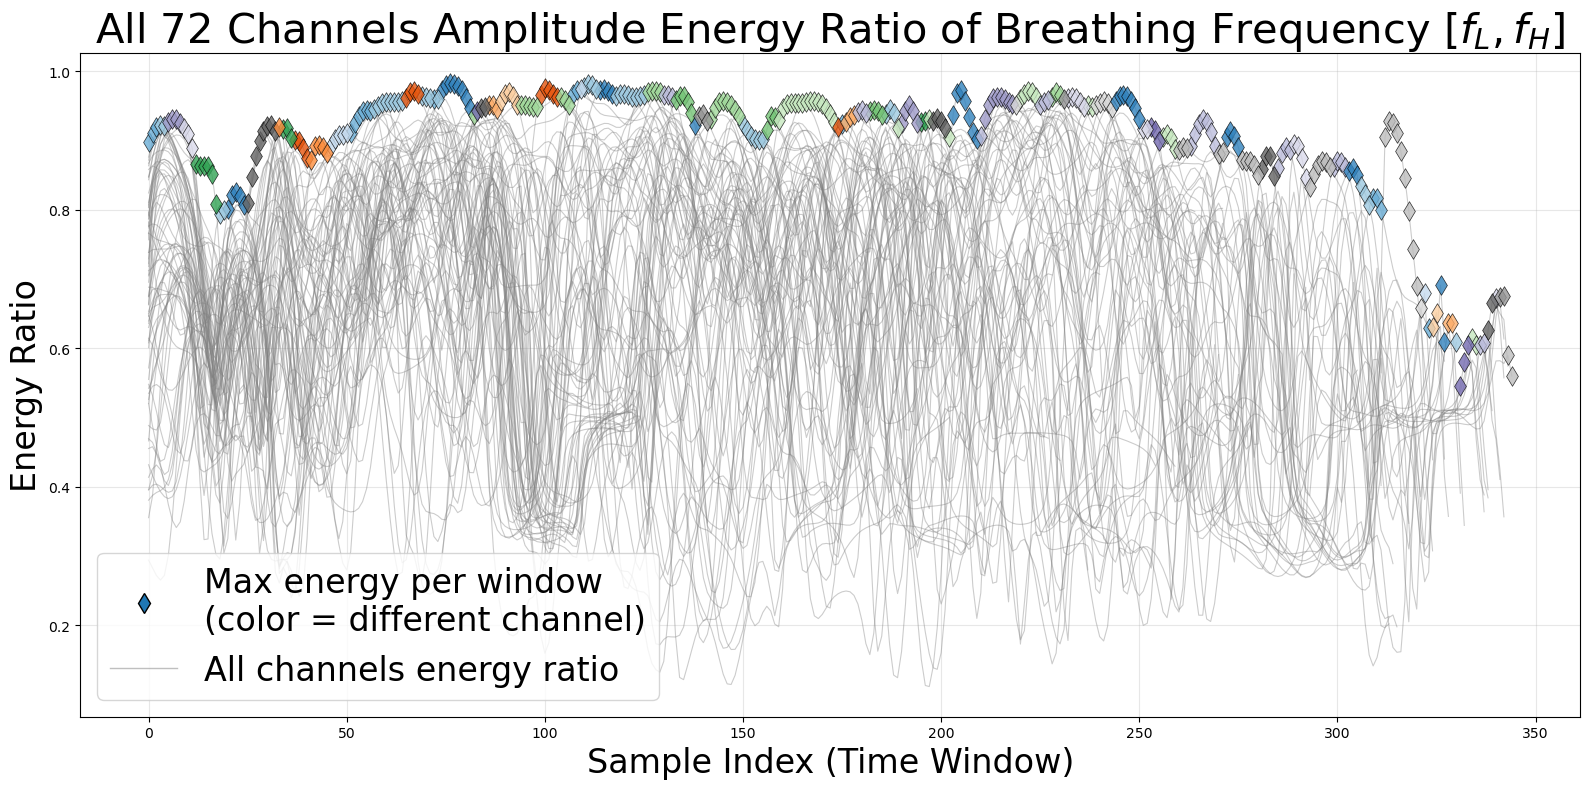


=== 所有信道能量占比统计（变量: remote_amplitudes）===
有效信道数: 72
时间窗数量: 184

作为能量占比最大的次数最多的前10个信道:
信道       次数       占比        
------------------------------
2        35       10.14     %
41       28       8.12      %
0        25       7.25      %
74       21       6.09      %
47       18       5.22      %
40       16       4.64      %
53       16       4.64      %
44       15       4.35      %
4        13       3.77      %
43       13       3.77      %


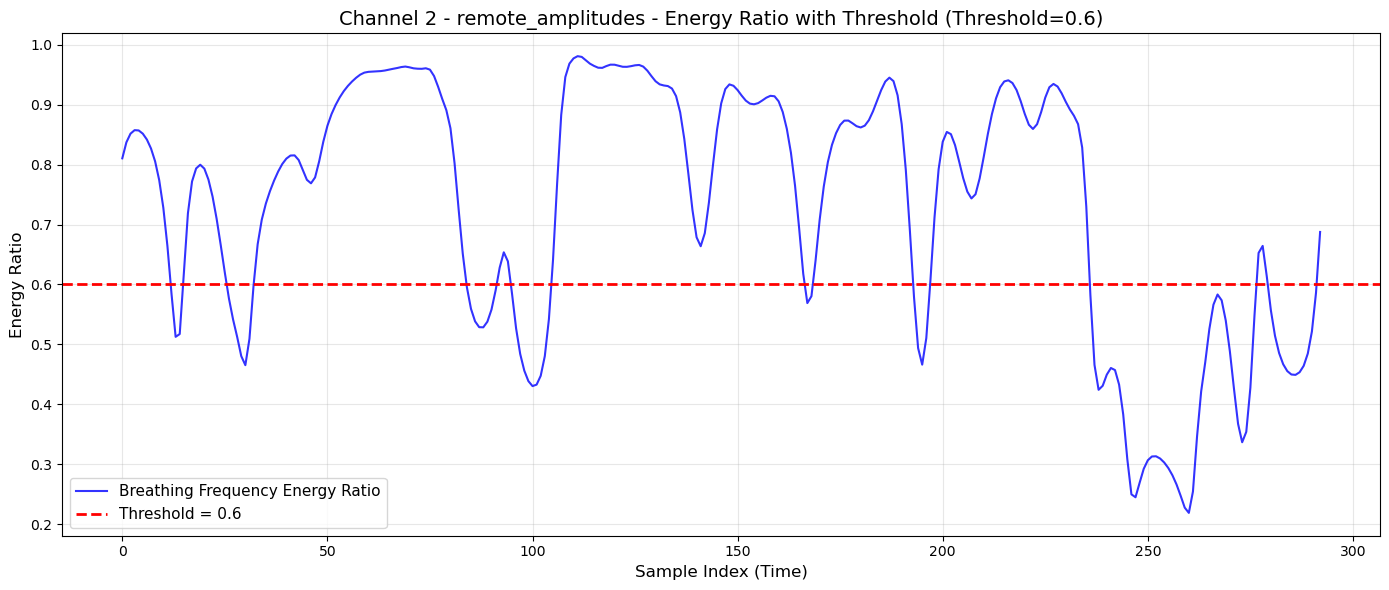


=== 阈值分析（阈值=0.6，仅用于 remote_amplitudes）===
阈值以上的样本数: 206 / 293 (70.3%)
阈值以下的样本数: 87 / 293 (29.7%)


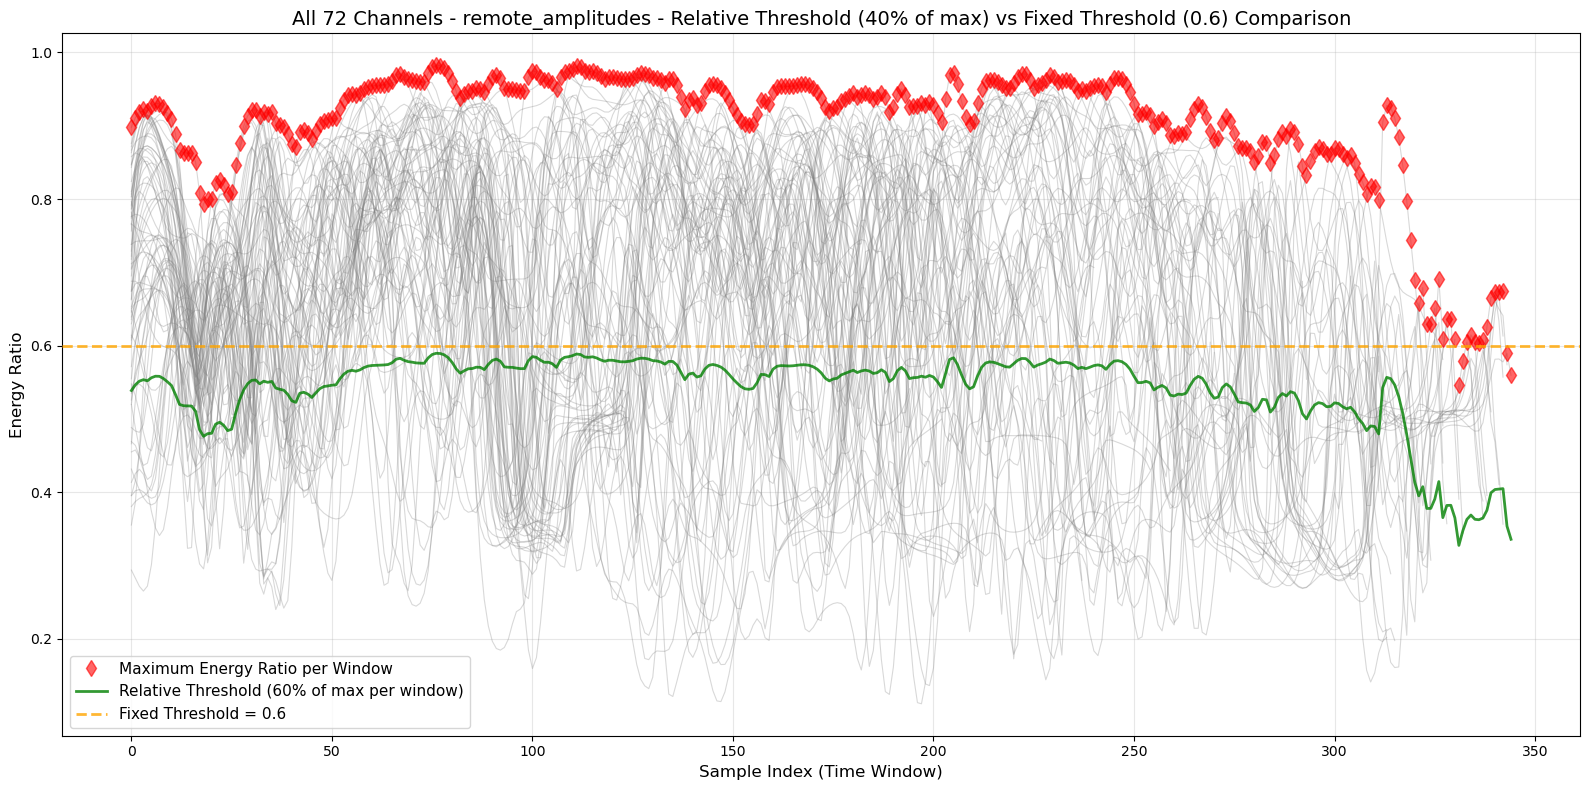


=== 相对阈值 vs 固定阈值对比分析 ===
相对阈值: 每个时间窗最大值的60%
固定阈值: 0.6

按时间窗统计（每个时间窗至少有一个信道超过阈值）:
  相对阈值: 184 / 345 个时间窗 (53.3%)
  固定阈值: 184 / 345 个时间窗 (53.3%)

按所有信道-时间窗组合统计:
  相对阈值: 9953 / 13248 个样本 (75.1%)
  固定阈值: 9158 / 13248 个样本 (69.1%)

相对阈值统计:
  平均值: 0.5415
  范围: [0.3274, 0.5895]
  固定阈值: 0.6000


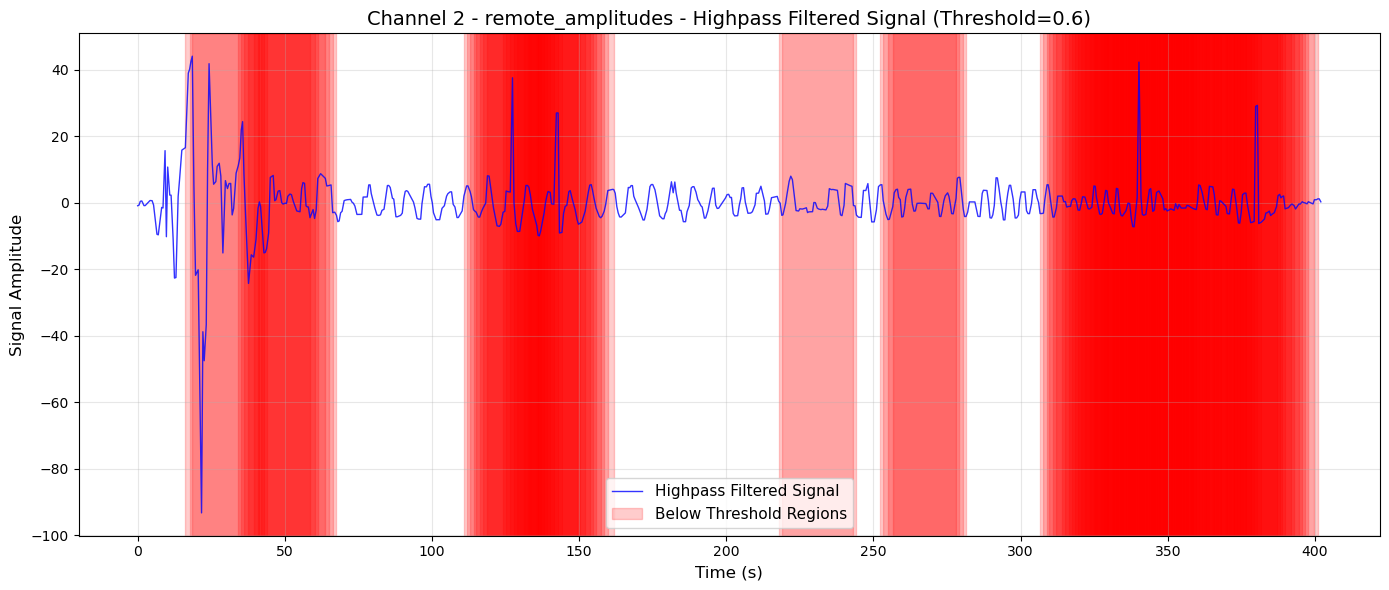

In [6]:
# 15-20秒时间窗，窗内计算呼吸【0.15-0.35】Hz这一范围占所有频率的能量比例
# 所有频率指【0.05-0.8】Hz,或着是上限设置为1/2 fs(2Hz)都可以。

# 参数设置
sampling_rate = 2.0  # Hz
window_length_sec = 20  # 时间窗长度（秒）
step_length_sec = 1  # 步长（秒）
window_length_samples = int(window_length_sec * sampling_rate)  # 20秒 = 40个样本点
step_length_samples = int(step_length_sec * sampling_rate)  # 1秒 = 2个样本点

# 呼吸频率范围
breath_freq_low = 0.1  # Hz
breath_freq_high = 0.35  # Hz
total_freq_low = 0.05  # Hz
total_freq_high = 0.8  # Hz

# # 选择通道和变量（用于展示）
# demo_channel = 0
# demo_variable = 'amplitudes'

# # 如果通道0不存在，使用第一个可用通道
# if demo_channel not in detrended_data and len(detrended_data) > 0:
#     demo_channel = list(detrended_data.keys())[0]
#     print(f"通道0不存在，使用通道 {demo_channel}")

# 存储所有通道和所有变量的分析结果
breathing_analysis_results = {}

# 遍历所有通道和所有变量，进行加窗和能量计算
print("开始对所有通道和所有变量进行加窗和能量计算...")
total_channels = len(detrended_data)
processed_channels = 0

for ch in detrended_data:
    breathing_analysis_results[ch] = {}
    ch_detrended = detrended_data[ch]
    
    # 遍历所有变量
    for var_name in ['amplitudes', 'phases', 'local_amplitudes', 'remote_amplitudes', 'local_phases', 'remote_phases']:
        if var_name in ch_detrended and 'detrended_order2' in ch_detrended[var_name]:
            # 获取高通滤波后的数据（使用order2）
            filtered_signal = ch_detrended[var_name]['detrended_order2']
            signal_length = len(filtered_signal)
            
            if signal_length < window_length_samples:
                # 信号太短，跳过
                continue
            
            # 对信号进行时间窗分割
            windowed_samples = []
            sample_indices = []
            
            start_idx = 0
            while start_idx + window_length_samples <= signal_length:
                # 提取一个时间窗
                window_data = filtered_signal[start_idx:start_idx + window_length_samples]
                
                # 应用Hanning窗
                hanning_window = np.hanning(len(window_data))
                windowed_data = window_data * hanning_window
                
                # 存储加窗后的样本
                windowed_samples.append(windowed_data)
                sample_indices.append(start_idx)
                
                # 移动到下一个窗口（步长为1秒）
                start_idx += step_length_samples
            
            # 对每个样本进行FFT并计算能量比例
            energy_ratios = []
            
            for i, windowed_data in enumerate(windowed_samples):
                # 计算FFT（使用rfft只计算正频率部分，更高效）
                fft_values = np.fft.rfft(windowed_data)
                fft_power = np.abs(fft_values) ** 2  # 功率谱
                
                # 计算频率轴（只包含正频率）
                fft_freq = np.fft.rfftfreq(len(windowed_data), 1.0 / sampling_rate)
                
                # 找到呼吸频率范围【0.15-0.35】Hz的索引
                breath_mask = (fft_freq >= breath_freq_low) & (fft_freq <= breath_freq_high)
                
                # 找到总频率范围【0.05-0.8】Hz的索引
                total_mask = (fft_freq >= total_freq_low) & (fft_freq <= total_freq_high)
                
                # 计算能量
                breath_energy = np.sum(fft_power[breath_mask])
                total_energy = np.sum(fft_power[total_mask])
                
                # 计算能量比例
                if total_energy > 0:
                    energy_ratio = breath_energy / total_energy
                else:
                    energy_ratio = 0.0
                
                energy_ratios.append(energy_ratio)
            
            # 存储该通道该变量的分析结果
            breathing_analysis_results[ch][var_name] = {
                'energy_ratios': np.array(energy_ratios),
                'windowed_samples': windowed_samples,
                'sample_indices': sample_indices,
                'filtered_signal': filtered_signal,
                'signal_length': signal_length
            }
    
    processed_channels += 1
    if processed_channels % 10 == 0 or processed_channels == total_channels:
        print(f"  已处理 {processed_channels}/{total_channels} 个通道...")

print(f"✓ 所有通道和变量的加窗和能量计算完成")


# 选择通道和变量（用于展示）
demo_channel = 2
demo_variable = 'remote_amplitudes'

# 如果通道0不存在，使用第一个可用通道
if demo_channel not in detrended_data and len(detrended_data) > 0:
    demo_channel = list(detrended_data.keys())[0]
    print(f"通道0不存在，使用通道 {demo_channel}")
    
# 检查demo_channel和demo_variable的数据是否存在
if demo_channel not in breathing_analysis_results or demo_variable not in breathing_analysis_results[demo_channel]:
    print(f"⚠️ 无法找到通道 {demo_channel} 的变量 {demo_variable}")
else:
    # 获取demo_variable的分析结果
    demo_results = breathing_analysis_results[demo_channel][demo_variable]
    breathing_energy_ratios = demo_results['energy_ratios']
    windowed_samples = demo_results['windowed_samples']
    sample_indices = demo_results['sample_indices']
    filtered_signal = demo_results['filtered_signal']
    signal_length = demo_results['signal_length']
    
    print(f"\n=== 展示通道 {demo_channel} 的变量 {demo_variable} ===")
    print(f"信号长度: {signal_length} 个样本点")
    print(f"时间窗长度: {window_length_sec}秒 ({window_length_samples}个样本点)")
    print(f"步长: {step_length_sec}秒 ({step_length_samples}个样本点)")
    print(f"✓ 共生成 {len(windowed_samples)} 个时间窗样本")
    print(f"✓ 能量比例计算完成，共 {len(breathing_energy_ratios)} 个样本")
    print(f"能量比例范围: [{np.min(breathing_energy_ratios):.4f}, {np.max(breathing_energy_ratios):.4f}]")
    print(f"平均能量比例: {np.mean(breathing_energy_ratios):.4f}")
    
    # 绘制能量占比图
    sample_numbers = np.arange(len(breathing_energy_ratios))
    time_axis = sample_numbers * step_length_sec  # 时间轴（秒）
    
    # 图1：能量占比曲线
    plt.figure(figsize=(14, 6))
    plt.plot(sample_numbers, breathing_energy_ratios, 'b-', linewidth=1.5, alpha=0.8, label='Breathing Frequency Energy Ratio')
    plt.xlabel('Sample Index (Time)', fontsize=12)
    plt.ylabel('Energy Ratio', fontsize=12)
    plt.title(f'Channel {demo_channel} - {demo_variable} - Energy Ratio of Breathing Frequency [{breath_freq_low}-{breath_freq_high}] Hz to Total Frequency [{total_freq_low}-{total_freq_high}] Hz', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # 图1.5：所有72个信道的能量占比曲线 + 每个时间窗中能量占比最大的信号标记
    # 收集所有信道的能量占比数据（使用demo_variable）
    print(f"\n正在收集所有信道的能量占比数据（变量: {demo_variable}）...")
    all_channels_energy_ratios = {}
    valid_channels = []
    
    for ch in breathing_analysis_results:
        if demo_variable in breathing_analysis_results[ch]:
            energy_ratios = breathing_analysis_results[ch][demo_variable]['energy_ratios']
            all_channels_energy_ratios[ch] = energy_ratios
            valid_channels.append(ch)
    
    print(f"✓ 找到 {len(valid_channels)} 个有效信道")
    
    if len(valid_channels) > 0:
        # 确定所有信道中时间窗数量的最大值（用于对齐）
        max_windows = max(len(all_channels_energy_ratios[ch]) for ch in valid_channels)
        min_windows = min(len(all_channels_energy_ratios[ch]) for ch in valid_channels)
        
        print(f"时间窗数量范围: {min_windows} - {max_windows}")
        
        # 创建图形
        plt.figure(figsize=(16, 8))
        
        # 绘制所有信道的能量占比曲线
        for ch in valid_channels:
            energy_ratios = all_channels_energy_ratios[ch]
            ch_sample_numbers = np.arange(len(energy_ratios))
            plt.plot(ch_sample_numbers, energy_ratios, '-', linewidth=0.8, alpha=0.4, color='gray', label=None)
        
        # 在每个时间窗中找到能量占比最大的信道
        # 使用最小的时间窗数量，确保所有信道都有数据
        max_energy_channels = []  # 存储每个时间窗中能量占比最大的信道
        max_energy_values = []    # 存储每个时间窗中的最大能量占比值
        
        for window_idx in range(max_windows):
            max_energy = -1
            max_ch = None
            
            for ch in valid_channels:
                if window_idx < len(all_channels_energy_ratios[ch]):
                    energy = all_channels_energy_ratios[ch][window_idx]
                    if energy > max_energy:
                        max_energy = energy
                        max_ch = ch
            
            if max_ch is not None:
                max_energy_channels.append(max_ch)
                max_energy_values.append(max_energy)
            else:
                max_energy_channels.append(None)
                max_energy_values.append(0)
        
        # 绘制每个时间窗中能量占比最大的点，根据所属信道使用不同颜色
        max_sample_numbers = np.arange(len(max_energy_values))
        
        # 为每个信道分配颜色（使用colormap）
        import matplotlib.cm as cm
        unique_channels = sorted(set(max_energy_channels))
        if None in unique_channels:
            unique_channels.remove(None)
        n_unique_channels = len(unique_channels)
        
        if n_unique_channels > 0:
            # 使用colormap为每个信道分配颜色
            colormap = cm.get_cmap('tab20')  # 使用tab20 colormap，支持20种不同颜色
            if n_unique_channels > 20:
                colormap = cm.get_cmap('tab20c')  # 如果信道数超过20，使用tab20c（支持更多颜色）
            
            channel_colors = {}
            for idx, ch in enumerate(unique_channels):
                channel_colors[ch] = colormap(idx % colormap.N)
            
            # 按信道分组绘制标记点
            for ch in unique_channels:
                ch_indices = [i for i, max_ch in enumerate(max_energy_channels) if max_ch == ch]
                if ch_indices:
                    ch_x = [max_sample_numbers[i] for i in ch_indices]
                    ch_y = [max_energy_values[i] for i in ch_indices]
                    plt.scatter(ch_x, ch_y, c=[channel_colors[ch]], marker='d', s=100, alpha=0.8, 
                              label=f'Channel {ch}', zorder=10, edgecolors='black', linewidths=0.5)
        
        # 添加图例和标签
        plt.xlabel('Sample Index (Time Window)', fontsize=24)
        plt.ylabel('Energy Ratio', fontsize=24)
        # plt.title(f'All {len(valid_channels)} Channels - {demo_variable} - Energy Ratio of Breathing Frequency [{breath_freq_low}-{breath_freq_high}] Hz\n(Colored stars indicate maximum energy ratio per time window, colored by channel)', fontsize=14)
        # plt.title(f'All {len(valid_channels)} Channels Amplitude Energy Ratio of Breathing Frequency [{breath_freq_low}-{breath_freq_high}] Hz', fontsize=28)
        plt.title(f'All {len(valid_channels)} Channels Amplitude Energy Ratio of Breathing Frequency'+r" $[f_L,f_H]$", fontsize=30)
        plt.grid(True, alpha=0.3)
        # plt.legend(fontsize=11)

        from matplotlib.lines import Line2D

        legend_elements = [
            Line2D([0], [0],
                marker='d',
                color='w',
                label='Max energy per window\n(color = different channel)',
                markerfacecolor='tab:blue',
                markeredgecolor='black',
                markersize=10),
            Line2D([0], [0],
                color='gray',
                lw=1,
                alpha=0.5,
                label='All channels energy ratio')
        ]

        plt.legend(handles=legend_elements,
                loc='best',
                fontsize=24,
                frameon=True,)



        plt.tight_layout()

        # 存储图片
        p = Path(filepath)
        output_path_png = out_dir / f"cs_show_energy_ratio{p.stem}.png"
        output_path_svg = out_dir / f"cs_show_energy_ratio{p.stem}.svg"
        output_path_pdf = out_dir / f"cs_show_energy_ratio{p.stem}.pdf"
        # plt.savefig(output_path_png, dpi=200)  
        # plt.savefig(output_path_svg, dpi=200)  
        plt.savefig(output_path_pdf, dpi=200) 

        plt.show()
        
        # 打印统计信息
        print(f"\n=== 所有信道能量占比统计（变量: {demo_variable}）===")
        print(f"有效信道数: {len(valid_channels)}")
        print(f"时间窗数量: {min_windows}")
        
        # 统计每个信道作为最大值的次数
        channel_max_count = {}
        for ch in valid_channels:
            channel_max_count[ch] = 0
        
        for max_ch in max_energy_channels:
            if max_ch is not None:
                channel_max_count[max_ch] = channel_max_count.get(max_ch, 0) + 1
        
        # 找出作为最大值次数最多的前10个信道
        sorted_channels = sorted(channel_max_count.items(), key=lambda x: x[1], reverse=True)
        print(f"\n作为能量占比最大的次数最多的前10个信道:")
        print(f"{'信道':<8} {'次数':<8} {'占比':<10}")
        print("-" * 30)
        for ch, count in sorted_channels[:10]:
            percentage = count / len(max_energy_channels) * 100 if len(max_energy_channels) > 0 else 0
            print(f"{ch:<8} {count:<8} {percentage:<10.2f}%")
    

    # 手动指定阈值（只用于demo_variable）
    threshold = 0.6
    
    # 图2：能量占比曲线 + 阈值线
    plt.figure(figsize=(14, 6))
    plt.plot(sample_numbers, breathing_energy_ratios, 'b-', linewidth=1.5, alpha=0.8, label='Breathing Frequency Energy Ratio')
    plt.axhline(y=threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold = {threshold}')
    plt.xlabel('Sample Index (Time)', fontsize=12)
    plt.ylabel('Energy Ratio', fontsize=12)
    plt.title(f'Channel {demo_channel} - {demo_variable} - Energy Ratio with Threshold (Threshold={threshold})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # 统计阈值以上的样本数量
    above_threshold = np.sum(breathing_energy_ratios >= threshold)
    below_threshold = len(breathing_energy_ratios) - above_threshold
    
    print(f"\n=== 阈值分析（阈值={threshold}，仅用于 {demo_variable}）===")
    print(f"阈值以上的样本数: {above_threshold} / {len(breathing_energy_ratios)} ({above_threshold/len(breathing_energy_ratios)*100:.1f}%)")
    print(f"阈值以下的样本数: {below_threshold} / {len(breathing_energy_ratios)} ({below_threshold/len(breathing_energy_ratios)*100:.1f}%)")
    
    # 图2.5：相对阈值（40%最大能量值）vs 固定阈值（0.6）对比
    # 使用所有信道的最大能量值来计算相对阈值
    # 如果图1.5已经计算了这些变量，直接使用；否则重新计算
    if len(valid_channels) > 0:
        # 检查是否已经计算了max_energy_values
        if 'max_energy_values' not in locals() or len(max_energy_values) == 0:
            # 重新计算max_energy_values
            if 'min_windows' not in locals():
                min_windows = min(len(all_channels_energy_ratios[ch]) for ch in valid_channels)
            
            max_energy_values = []
            for window_idx in range(min_windows):
                max_energy = -1
                for ch in valid_channels:
                    if window_idx < len(all_channels_energy_ratios[ch]):
                        energy = all_channels_energy_ratios[ch][window_idx]
                        if energy > max_energy:
                            max_energy = energy
                max_energy_values.append(max_energy if max_energy > 0 else 0)
        
        if len(max_energy_values) > 0:
            # 计算相对阈值：每个时间窗最大值的百分比%
            relative_threshold_ratio = 0.6
            relative_thresholds = [max_val * relative_threshold_ratio for max_val in max_energy_values]
            
            # 创建图形
            plt.figure(figsize=(16, 8))
            
            # 绘制所有信道的能量占比曲线（灰色背景）
            for ch in valid_channels:
                energy_ratios = all_channels_energy_ratios[ch]
                ch_sample_numbers = np.arange(len(energy_ratios))
                plt.plot(ch_sample_numbers, energy_ratios, '-', linewidth=0.8, alpha=0.3, color='gray', label=None)
            
            # 绘制每个时间窗的最大能量值（红色星号）
            max_sample_numbers = np.arange(len(max_energy_values))
            plt.plot(max_sample_numbers, max_energy_values, 'rd', markersize=8, alpha=0.6, 
                    label=f'Maximum Energy Ratio per Window', zorder=5)
            
            # 绘制相对阈值线（每个时间窗最大值的X0%）
            plt.plot(max_sample_numbers, relative_thresholds, 'g-', linewidth=2, alpha=0.8, 
                    label=f'Relative Threshold ({relative_threshold_ratio*100:.0f}% of max per window)', zorder=6)
            
            # 绘制固定阈值线（0.6）
            fixed_threshold = 0.6
            plt.axhline(y=fixed_threshold, color='orange', linestyle='--', linewidth=2, alpha=0.8, 
                    label=f'Fixed Threshold = {fixed_threshold}', zorder=7)
            
            # 添加图例和标签
            plt.xlabel('Sample Index (Time Window)', fontsize=12)
            plt.ylabel('Energy Ratio', fontsize=12)
            plt.title(f'All {len(valid_channels)} Channels - {demo_variable} - Relative Threshold (40% of max) vs Fixed Threshold (0.6) Comparison', fontsize=14)
            plt.grid(True, alpha=0.3)
            plt.legend(fontsize=11, loc='best')
            plt.tight_layout()
            plt.show()
        
            # 统计两种阈值下的样本数量
            # 对于相对阈值，需要检查每个时间窗中是否有信道超过该时间窗的相对阈值
            # 对于固定阈值，检查每个时间窗中是否有信道超过固定阈值
            relative_above_count = 0
            fixed_above_count = 0
            total_windows = len(max_energy_values)
            
            for window_idx in range(min_windows):
                # 检查该时间窗中是否有信道超过相对阈值
                relative_thresh = relative_thresholds[window_idx]
                for ch in valid_channels:
                    if window_idx < len(all_channels_energy_ratios[ch]):
                        if all_channels_energy_ratios[ch][window_idx] >= relative_thresh:
                            relative_above_count += 1
                            break  # 只要有一个信道超过就计数
                
                # 检查该时间窗中是否有信道超过固定阈值
                for ch in valid_channels:
                    if window_idx < len(all_channels_energy_ratios[ch]):
                        if all_channels_energy_ratios[ch][window_idx] >= fixed_threshold:
                            fixed_above_count += 1
                            break  # 只要有一个信道超过就计数
            
            # 另一种统计方式：统计所有信道-时间窗组合中超过阈值的数量
            relative_above_all = 0
            fixed_above_all = 0
            total_samples = 0
            
            for window_idx in range(min_windows):
                for ch in valid_channels:
                    if window_idx < len(all_channels_energy_ratios[ch]):
                        total_samples += 1
                        energy = all_channels_energy_ratios[ch][window_idx]
                        if energy >= relative_thresholds[window_idx]:
                            relative_above_all += 1
                        if energy >= fixed_threshold:
                            fixed_above_all += 1
            
            print(f"\n=== 相对阈值 vs 固定阈值对比分析 ===")
            print(f"相对阈值: 每个时间窗最大值的{relative_threshold_ratio*100:.0f}%")
            print(f"固定阈值: {fixed_threshold}")
            print(f"\n按时间窗统计（每个时间窗至少有一个信道超过阈值）:")
            print(f"  相对阈值: {relative_above_count} / {total_windows} 个时间窗 ({relative_above_count/total_windows*100:.1f}%)")
            print(f"  固定阈值: {fixed_above_count} / {total_windows} 个时间窗 ({fixed_above_count/total_windows*100:.1f}%)")
            print(f"\n按所有信道-时间窗组合统计:")
            print(f"  相对阈值: {relative_above_all} / {total_samples} 个样本 ({relative_above_all/total_samples*100:.1f}%)")
            print(f"  固定阈值: {fixed_above_all} / {total_samples} 个样本 ({fixed_above_all/total_samples*100:.1f}%)")
            
            # 计算相对阈值的平均值和范围
            avg_relative_threshold = np.mean(relative_thresholds)
            min_relative_threshold = np.min(relative_thresholds)
            max_relative_threshold = np.max(relative_thresholds)
            print(f"\n相对阈值统计:")
            print(f"  平均值: {avg_relative_threshold:.4f}")
            print(f"  范围: [{min_relative_threshold:.4f}, {max_relative_threshold:.4f}]")
            print(f"  固定阈值: {fixed_threshold:.4f}")
    
    # 图3：高通滤波后的信号 + 低于阈值的区间背景标记
    # 获取时间轴
    timestamps_ms = all_channels_data[demo_channel]['timestamps_ms']
    if len(timestamps_ms) > 0:
        time_sec = (timestamps_ms - timestamps_ms[0]) / 1000.0
    else:
        time_sec = np.arange(len(filtered_signal)) / sampling_rate
    
    # 确保时间轴长度与信号长度匹配
    if len(time_sec) != len(filtered_signal):
        time_sec = np.arange(len(filtered_signal)) / sampling_rate
    
    plt.figure(figsize=(14, 6))
    ax = plt.gca()
    
    # 绘制高通滤波后的信号
    ax.plot(time_sec, filtered_signal, 'b-', linewidth=1.0, alpha=0.8, label='Highpass Filtered Signal')
    
    # 标记低于阈值的区间
    # 找到所有低于阈值的样本
    below_threshold_samples = np.where(breathing_energy_ratios < threshold)[0]
    
    # 为每个低于阈值的样本绘制背景区域
    label_added = False
    for sample_idx in below_threshold_samples:
        # 使用sample_indices获取该样本的起始索引
        if sample_idx < len(sample_indices):
            start_idx = sample_indices[sample_idx]
            end_idx = start_idx + window_length_samples
            
            # 确保索引在有效范围内
            if end_idx <= len(time_sec):
                start_time = time_sec[start_idx]
                end_time = time_sec[end_idx - 1] if end_idx > 0 else time_sec[-1]
            else:
                # 如果超出范围，使用最后一个时间点
                start_time = time_sec[start_idx] if start_idx < len(time_sec) else time_sec[-1]
                end_time = time_sec[-1]
        else:
            # 如果sample_indices不可用，使用近似计算
            start_time = sample_idx * step_length_sec
            end_time = start_time + window_length_sec
            start_time = max(start_time, time_sec[0])
            end_time = min(end_time, time_sec[-1])
        
        # 绘制浅红色背景区域
        if not label_added:
            ax.axvspan(start_time, end_time, alpha=0.2, color='red', label='Below Threshold Regions')
            label_added = True
        else:
            ax.axvspan(start_time, end_time, alpha=0.2, color='red')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Signal Amplitude', fontsize=12)
    ax.set_title(f'Channel {demo_channel} - {demo_variable} - Highpass Filtered Signal (Threshold={threshold})', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()


# add.3 带通滤波
保留呼吸
- 通带：
  - **0.15 – 0.35 Hz**
  - 0.15稍大，换0.1
- 阶数：
  - **2 阶 Butterworth**
- 滤波方式：
  - 零相位


Applying bandpass filter to windowed data...
Sampling rate: 2.0 Hz
Passband: 0.1 - 0.35 Hz
Threshold for energy ratio: 0.6
开始对所有通道和所有变量进行带通滤波...
已处理 10/72 个通道...
已处理 20/72 个通道...
已处理 30/72 个通道...
已处理 40/72 个通道...
已处理 50/72 个通道...
已处理 60/72 个通道...
已处理 70/72 个通道...
已处理 72/72 个通道...
✓ Bandpass filtering and frequency estimation completed for all channels and variables


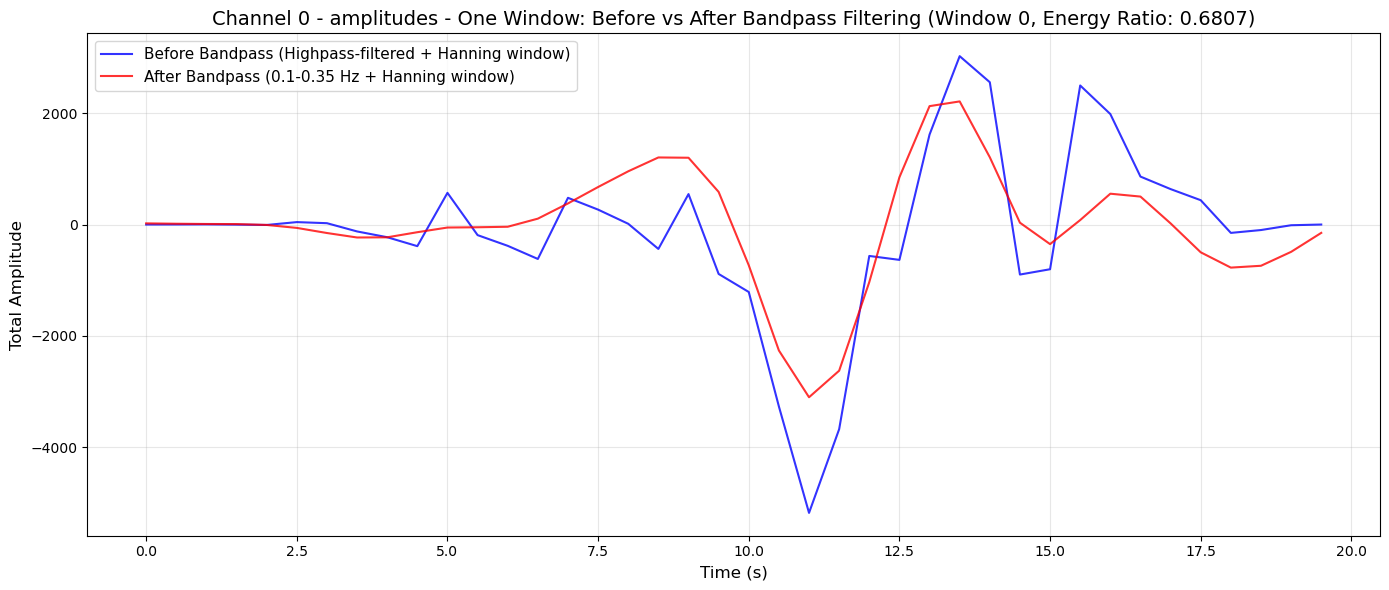

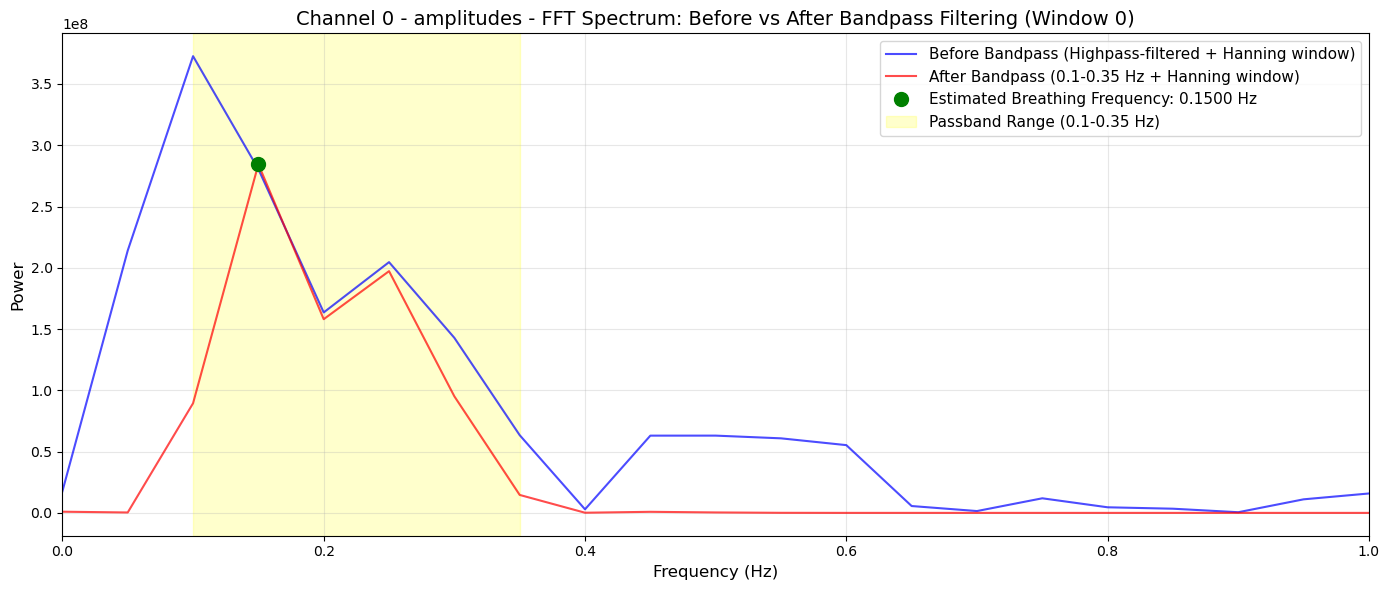

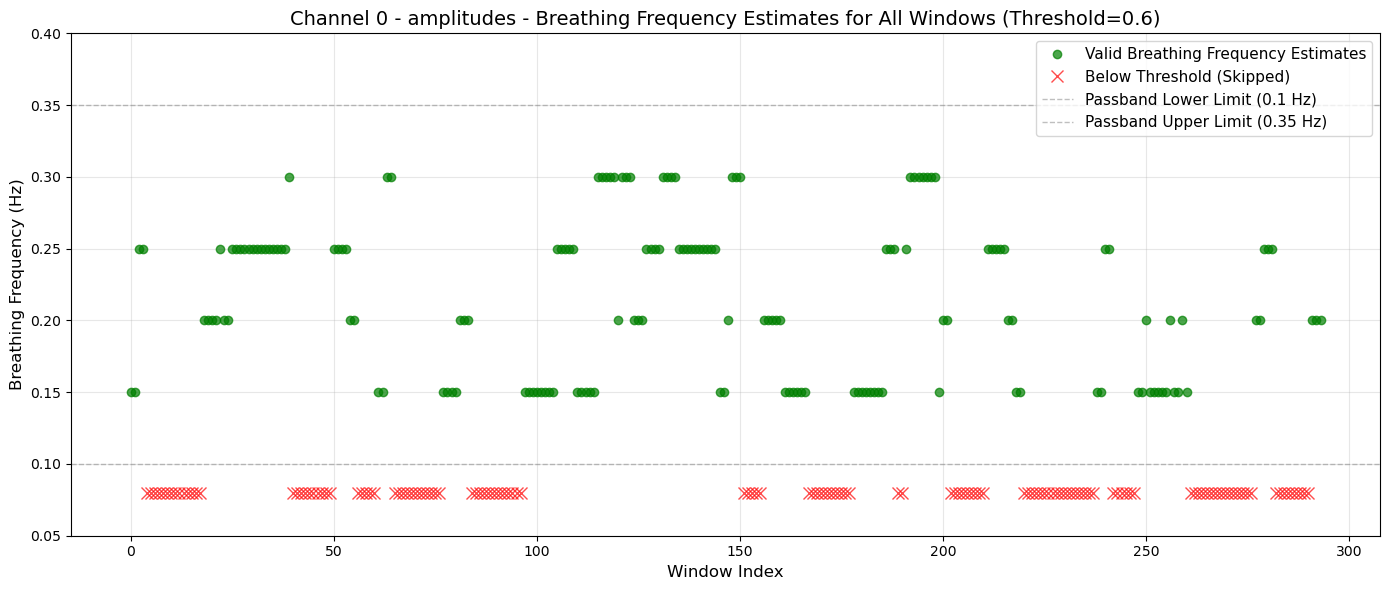


=== Channel 0 - Total Amplitude - Breathing Frequency Statistics ===
Total windows: 294
Valid windows (above threshold): 164 (55.8%)
Invalid windows (below threshold): 130 (44.2%)

Valid breathing frequency estimates:
  Mean: 0.2159 Hz
  Std: 0.0537 Hz
  Min: 0.1500 Hz
  Max: 0.3000 Hz


In [7]:
# Apply bandpass filter to windowed data (only for windows with energy ratio above threshold)
# Use the windowed data from breathing_analysis_results

# Parameters
sampling_rate = 2.0  # Hz (2 Hz sampling rate as mentioned)
lowcut = 0.1  # Hz (low cutoff frequency for breathing range)
highcut = 0.35  # Hz (high cutoff frequency for breathing range)
threshold = 0.6  # Same threshold as used in breathing detection

print(f"\nApplying bandpass filter to windowed data...")
print(f"Sampling rate: {sampling_rate} Hz")
print(f"Passband: {lowcut} - {highcut} Hz")
print(f"Threshold for energy ratio: {threshold}")

# Check if breathing_analysis_results exists
if "breathing_analysis_results" not in globals():
    print(
        "⚠️ breathing_analysis_results not found. Please run the breathing detection section first."
    )
else:
    # Store bandpass filtered results and breathing frequency estimates
    bandpass_results = {}
    breathing_freq_estimates = {}

    # Process all channels and variables
    print("开始对所有通道和所有变量进行带通滤波...")
    total_channels = len(detrended_data)
    processed_channels = 0
    for ch in breathing_analysis_results:
        bandpass_results[ch] = {}
        breathing_freq_estimates[ch] = {}

        for var_name in breathing_analysis_results[ch]:
            energy_ratios = breathing_analysis_results[ch][var_name]["energy_ratios"]
            windowed_samples = breathing_analysis_results[ch][var_name][
                "windowed_samples"
            ]

            # Apply bandpass filter to each window (only if energy ratio >= threshold)
            bandpass_filtered_windows = []
            breathing_freqs = []  # Store breathing frequency estimates for each window

            for i, (windowed_data, energy_ratio) in enumerate(
                zip(windowed_samples, energy_ratios)
            ):
                if energy_ratio >= threshold:
                    # Apply bandpass filter directly to the windowed data
                    # Note: windowed_data is already windowed with Hanning window
                    # We apply bandpass filter to the windowed data
                    bandpass_windowed = apply_filter_pipeline(
                        windowed_data,
                        fs=sampling_rate,
                        pipeline=[
                            {
                                "type": "bandpass",
                                "lowcut": lowcut,
                                "highcut": highcut,
                                "order": 2,
                            }
                        ],
                    )

                    bandpass_filtered_windows.append(bandpass_windowed)

                    # Use FFT to estimate breathing frequency (find frequency with maximum energy)
                    fft_values = np.fft.rfft(bandpass_windowed)
                    fft_power = np.abs(fft_values) ** 2
                    fft_freq = np.fft.rfftfreq(
                        len(bandpass_windowed), 1.0 / sampling_rate
                    )

                    # Find frequency range within [lowcut, highcut]
                    freq_mask = (fft_freq >= lowcut) & (fft_freq <= highcut)
                    if np.any(freq_mask):
                        # Find frequency with maximum power in the passband
                        max_power_idx = np.argmax(fft_power[freq_mask])
                        # Get the actual index in fft_freq
                        freq_indices = np.where(freq_mask)[0]
                        max_freq_idx = freq_indices[max_power_idx]
                        breathing_freq = fft_freq[max_freq_idx]
                    else:
                        breathing_freq = np.nan

                    breathing_freqs.append(breathing_freq)
                else:
                    # Energy ratio below threshold, skip this window
                    bandpass_filtered_windows.append(None)
                    breathing_freqs.append(np.nan)  # Mark as invalid

            bandpass_results[ch][var_name] = {
                "bandpass_filtered_windows": bandpass_filtered_windows,
                "energy_ratios": energy_ratios,
                "sample_indices": breathing_analysis_results[ch][var_name][
                    "sample_indices"
                ],
            }

            breathing_freq_estimates[ch][var_name] = np.array(breathing_freqs)

        processed_channels += 1
        if processed_channels % 10 == 0 or processed_channels == total_channels:
            print(f"已处理 {processed_channels}/{total_channels} 个通道...")

    print(
        f"✓ Bandpass filtering and frequency estimation completed for all channels and variables"
    )


# Visualize results for demo_variable
# Select a channel and variable for demonstration
demo_channel = 0
demo_variable = "amplitudes"

# If channel 0 doesn't exist, use the first available channel
if (
    demo_channel not in breathing_analysis_results
    and len(breathing_analysis_results) > 0
):
    demo_channel = list(breathing_analysis_results.keys())[0]
    print(f"通道0不存在，使用通道 {demo_channel}")

if demo_channel in bandpass_results and demo_variable in bandpass_results[demo_channel]:
    # Get data
    bandpass_windows = bandpass_results[demo_channel][demo_variable][
        "bandpass_filtered_windows"
    ]
    energy_ratios = bandpass_results[demo_channel][demo_variable]["energy_ratios"]
    sample_indices = bandpass_results[demo_channel][demo_variable]["sample_indices"]
    breathing_freqs = breathing_freq_estimates[demo_channel][demo_variable]

    # Get original windowed samples (before bandpass)
    original_windowed_samples = breathing_analysis_results[demo_channel][demo_variable][
        "windowed_samples"
    ]

    # Variable name mapping
    var_names = {
        "amplitudes": "Total Amplitude",
        "phases": "Total Phase",
        "local_amplitudes": "Local Amplitude",
        "remote_amplitudes": "Remote Amplitude",
        "local_phases": "Local Phase",
        "remote_phases": "Remote Phase",
    }
    var_display_name = var_names.get(demo_variable, demo_variable)

    # Find a window with energy ratio above threshold for demonstration
    demo_window_idx = None
    for i, (energy_ratio, bp_window) in enumerate(zip(energy_ratios, bandpass_windows)):
        if energy_ratio >= threshold and bp_window is not None:
            demo_window_idx = i
            break

    # Plot 1: One window - before and after bandpass filtering
    if demo_window_idx is not None:
        original_window = original_windowed_samples[demo_window_idx]
        bandpass_window = bandpass_windows[demo_window_idx]

        # Create time axis for this window
        window_time = np.arange(len(original_window)) / sampling_rate

        plt.figure(figsize=(14, 6))
        plt.plot(
            window_time,
            original_window,
            "b-",
            linewidth=1.5,
            alpha=0.8,
            label="Before Bandpass (Highpass-filtered + Hanning window)",
        )
        plt.plot(
            window_time,
            bandpass_window,
            "r-",
            linewidth=1.5,
            alpha=0.8,
            label=f"After Bandpass ({lowcut}-{highcut} Hz + Hanning window)",
        )
        plt.xlabel("Time (s)", fontsize=12)
        plt.ylabel(var_display_name, fontsize=12)
        plt.title(
            f"Channel {demo_channel} - {demo_variable} - One Window: Before vs After Bandpass Filtering (Window {demo_window_idx}, Energy Ratio: {energy_ratios[demo_window_idx]:.4f})",
            fontsize=14,
        )
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No window found with energy ratio above threshold for demonstration")

    # Plot 2: FFT spectrum of one window (before and after bandpass)
    if demo_window_idx is not None:
        original_window = original_windowed_samples[demo_window_idx]
        bandpass_window = bandpass_windows[demo_window_idx]

        # Compute FFT for original window (before bandpass)
        fft_original = np.fft.rfft(original_window)
        fft_power_original = np.abs(fft_original) ** 2
        fft_freq_original = np.fft.rfftfreq(len(original_window), 1.0 / sampling_rate)

        # Compute FFT for bandpass window (after bandpass)
        fft_bandpass = np.fft.rfft(bandpass_window)
        fft_power_bandpass = np.abs(fft_bandpass) ** 2
        fft_freq_bandpass = np.fft.rfftfreq(len(bandpass_window), 1.0 / sampling_rate)

        # Find the estimated breathing frequency for this window
        estimated_freq = breathing_freqs[demo_window_idx]

        plt.figure(figsize=(14, 6))
        plt.plot(
            fft_freq_original,
            fft_power_original,
            "b-",
            linewidth=1.5,
            alpha=0.7,
            label="Before Bandpass (Highpass-filtered + Hanning window)",
        )
        plt.plot(
            fft_freq_bandpass,
            fft_power_bandpass,
            "r-",
            linewidth=1.5,
            alpha=0.7,
            label=f"After Bandpass ({lowcut}-{highcut} Hz + Hanning window)",
        )

        # Mark the estimated breathing frequency
        if not np.isnan(estimated_freq):
            # Find the power at estimated frequency
            freq_idx = np.argmin(np.abs(fft_freq_bandpass - estimated_freq))
            power_at_freq = fft_power_bandpass[freq_idx]
            plt.plot(
                estimated_freq,
                power_at_freq,
                "go",
                markersize=10,
                label=f"Estimated Breathing Frequency: {estimated_freq:.4f} Hz",
            )

        # Mark passband range
        plt.axvspan(
            lowcut,
            highcut,
            alpha=0.2,
            color="yellow",
            label=f"Passband Range ({lowcut}-{highcut} Hz)",
        )

        plt.xlabel("Frequency (Hz)", fontsize=12)
        plt.ylabel("Power", fontsize=12)
        plt.title(
            f"Channel {demo_channel} - {demo_variable} - FFT Spectrum: Before vs After Bandpass Filtering (Window {demo_window_idx})",
            fontsize=14,
        )
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=11)
        plt.xlim([0, 1.0])  # Focus on frequency range up to 1 Hz
        plt.tight_layout()
        plt.show()

    # Plot 3: Breathing frequency estimates for all windows
    sample_numbers = np.arange(len(breathing_freqs))
    valid_mask = ~np.isnan(breathing_freqs)
    invalid_mask = np.isnan(breathing_freqs)

    plt.figure(figsize=(14, 6))

    # Plot valid frequency estimates
    if np.any(valid_mask):
        plt.plot(
            sample_numbers[valid_mask],
            breathing_freqs[valid_mask],
            "go",
            markersize=6,
            alpha=0.7,
            label="Valid Breathing Frequency Estimates",
        )

    # Mark invalid windows (below threshold)
    if np.any(invalid_mask):
        plt.plot(
            sample_numbers[invalid_mask],
            [lowcut - 0.02] * np.sum(invalid_mask),
            "rx",
            markersize=8,
            alpha=0.7,
            label="Below Threshold (Skipped)",
        )

    plt.axhline(
        y=lowcut,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        label=f"Passband Lower Limit ({lowcut} Hz)",
    )
    plt.axhline(
        y=highcut,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        label=f"Passband Upper Limit ({highcut} Hz)",
    )
    plt.xlabel("Window Index", fontsize=12)
    plt.ylabel("Breathing Frequency (Hz)", fontsize=12)
    plt.title(
        f"Channel {demo_channel} - {demo_variable} - Breathing Frequency Estimates for All Windows (Threshold={threshold})",
        fontsize=14,
    )
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.ylim([lowcut - 0.05, highcut + 0.05])
    plt.tight_layout()
    plt.show()

    # Print statistics
    valid_freqs = breathing_freqs[valid_mask]
    if len(valid_freqs) > 0:
        print(
            f"\n=== Channel {demo_channel} - {var_display_name} - Breathing Frequency Statistics ==="
        )
        print(f"Total windows: {len(breathing_freqs)}")
        print(
            f"Valid windows (above threshold): {np.sum(valid_mask)} ({np.sum(valid_mask)/len(breathing_freqs)*100:.1f}%)"
        )
        print(
            f"Invalid windows (below threshold): {np.sum(invalid_mask)} ({np.sum(invalid_mask)/len(breathing_freqs)*100:.1f}%)"
        )
        print(f"\nValid breathing frequency estimates:")
        print(f"  Mean: {np.mean(valid_freqs):.4f} Hz")
        print(f"  Std: {np.std(valid_freqs):.4f} Hz")
        print(f"  Min: {np.min(valid_freqs):.4f} Hz")
        print(f"  Max: {np.max(valid_freqs):.4f} Hz")
    else:
        print(
            f"\n⚠️ No valid breathing frequency estimates found (all windows below threshold)"
        )
else:
    print(
        f"⚠️ Cannot find channel {demo_channel} variable {demo_variable} in bandpass_results"
    )